In [3]:
!pip install gdown numpy pandas torch torchvision matplotlib seaborn scikit-learn scipy tqdm  -q

In [2]:
import gdown
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [4]:
data_dir = os.getcwd()
output_path = os.path.join(os.getcwd(), "Essays.csv")
if os.path.exists(output_path):
    print("Dataset already exists, skipping Downloading....")
else:
    file_id = "1S5U2HWtJuXWmLYbkoxfTT8UHRuReX9Rq"
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output=output_path, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1S5U2HWtJuXWmLYbkoxfTT8UHRuReX9Rq
To: /content/Essays.csv
100%|██████████| 36.2M/36.2M [00:00<00:00, 96.0MB/s]


In [5]:
df = pd.read_csv(output_path)

In [6]:
df.shape

(17307, 3)

In [9]:
df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [10]:
df.isnull().sum()

,0
essay_id,0
full_text,0
score,0


# EDA

In [7]:
score_counts = df["score"].value_counts().sort_index()

In [8]:
score_counts

,count
score,
1,1252
2,4723
3,6280
4,3926
5,970
6,156


In [9]:
word_counts = df["full_text"].str.split().str.len()
word_counts = word_counts[word_counts.notna()]

In [10]:
word_counts.describe()

,full_text
count,17307.000000
mean,368.348241
std,150.394776
min,150.000000
25%,253.000000
50%,345.000000
75%,452.000000
max,1656.000000


In [16]:
score_counts

,count
score,
1,1252
2,4723
3,6280
4,3926
5,970
6,156


In [26]:
score_counts.max()

6280

In [19]:
score_counts.max() / score_counts.sum()

np.float64(0.36285895880279656)

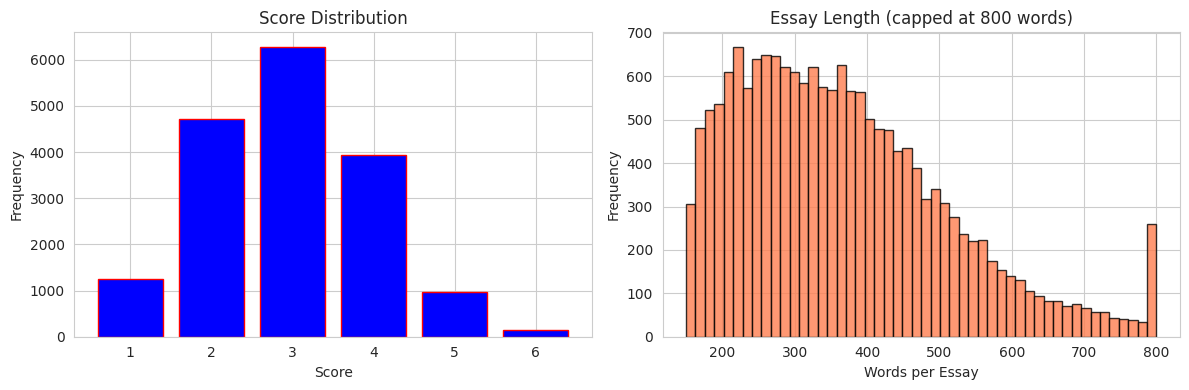

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
score_count_axis = axes[0]
word_count_axis = axes[1]
score_count_axis.bar(score_counts.index, score_counts.values, color="blue", edgecolor="red")
score_count_axis.set_xlabel("Score")
score_count_axis.set_ylabel("Frequency")
score_count_axis.set_title("Score Distribution")
score_count_axis.set_xticks(score_counts.index)

word_cap = 800


word_count_axis.hist(word_counts.clip(upper=word_cap), bins=50, color="coral", edgecolor="black", alpha=0.8)
word_count_axis.set_xlabel("Words per Essay")
word_count_axis.set_ylabel("Frequency")
word_count_axis.set_title(f"Essay Length (capped at {word_cap} words)")

plt.tight_layout()
plt.show()

In [30]:
more_than_600 = (word_counts[word_counts > 600]).count()

In [31]:
more_than_600 / word_counts.count()

np.float64(0.07401629398509274)

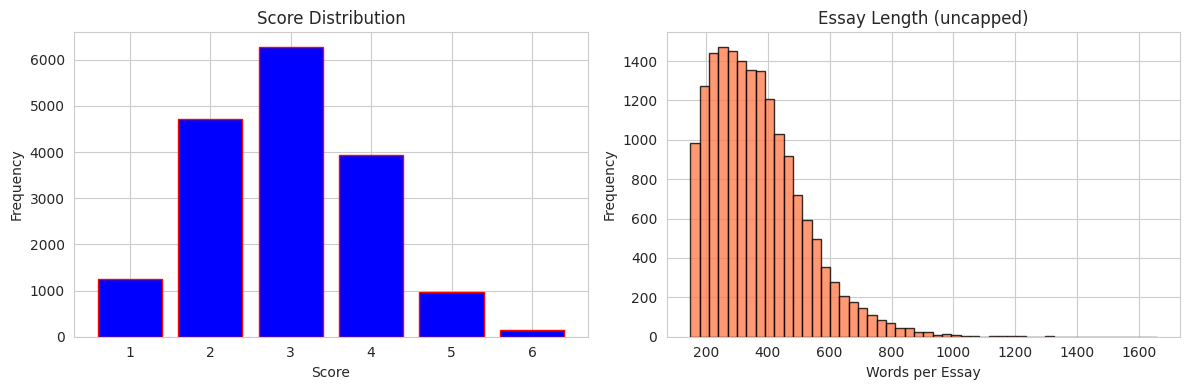

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
score_count_axis = axes[0]
word_count_axis = axes[1]
score_count_axis.bar(score_counts.index, score_counts.values, color="blue", edgecolor="red")
score_count_axis.set_xlabel("Score")
score_count_axis.set_ylabel("Frequency")
score_count_axis.set_title("Score Distribution")
score_count_axis.set_xticks(score_counts.index)

# word_cap = 800


word_count_axis.hist(word_counts, bins=50, color="coral", edgecolor="black", alpha=0.8)
word_count_axis.set_xlabel("Words per Essay")
word_count_axis.set_ylabel("Frequency")
word_count_axis.set_title(f"Essay Length (uncapped)")

plt.tight_layout()
plt.show()

In [16]:
df["cleaned_full_text"] = df["full_text"].str.strip()
df["word_count"] = df["cleaned_full_text"].str.split().str.len()

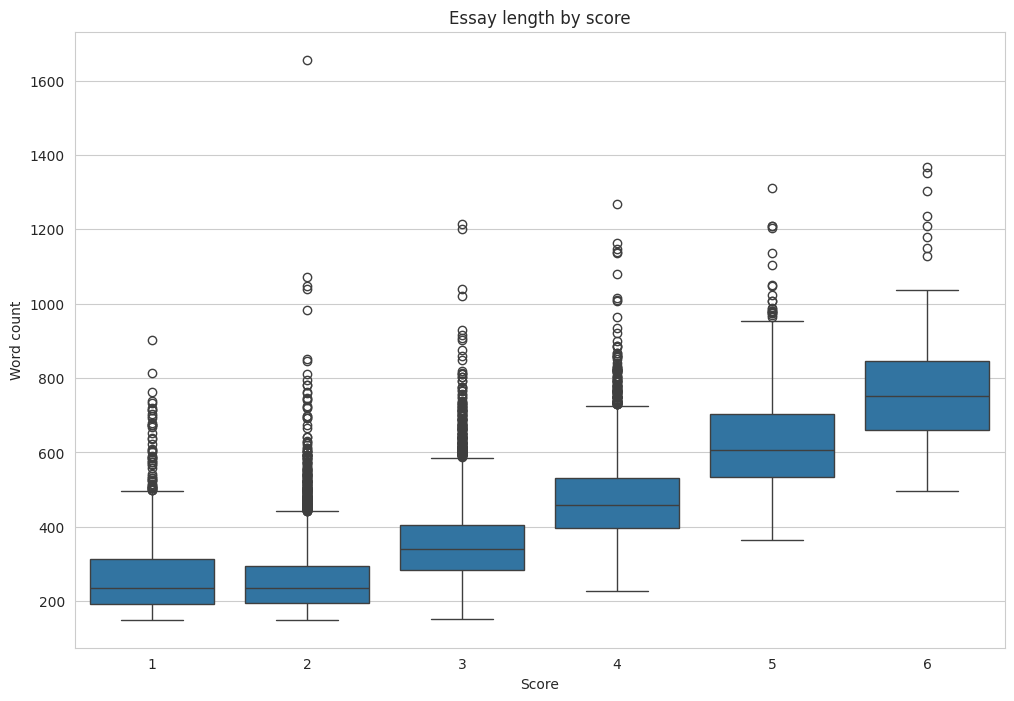

In [17]:
sns.boxplot(data=df, x="score", y="word_count")
plt.xlabel("Score")
plt.ylabel("Word count")
plt.title("Essay length by score")
plt.show()

#Data Preprocessing

In [18]:
def stratified_split(X, y, val_ratio=0.15, test_ratio=0.15, random_state=RANDOM_STATE):
    X_rest, X_test, y_rest, y_test = train_test_split(
        X, y, test_size=test_ratio, stratify=y, random_state=random_state
    )
    val_size = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(
        X_rest, y_rest, test_size=val_size, stratify=y_rest, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [19]:
X = df["full_text"].fillna("").astype(str)
y = df["score"].astype(int)
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(X, y)

In [20]:
print(f"Training: {len(y_train)}")
print(f"Validation: {len(y_val)}")
print(f"Test: {len(y_test)}")

Training: 12114
Validation: 2596
Test: 2597


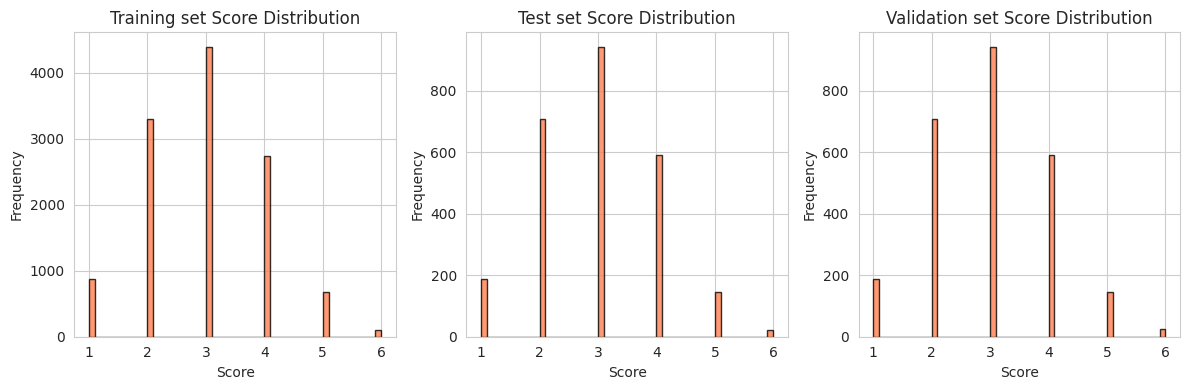

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(y_train.values, bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Training set Score Distribution")

axes[1].hist(y_test.values, bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Test set Score Distribution")

axes[2].hist(y_val.values, bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Validation set Score Distribution")

plt.tight_layout()
plt.show()

# Feature Engineering

In [23]:
word_max_features = 5_000 #20_000
char_max_features = 3_000 #15_000

In [24]:
tfidf_word = TfidfVectorizer(ngram_range=(1, 2), max_features=word_max_features, min_df=2, sublinear_tf=True)
tfidf_char = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), max_features=char_max_features, min_df=2)

In [25]:
def fit_vectorizers(X_tr):
    W = tfidf_word.fit_transform(X_tr)
    C = tfidf_char.fit_transform(X_tr)
    return np.hstack([W.toarray(), C.toarray()])

In [26]:
def transform_vectorizers(X, fit_word=False, fit_char=False):
    if fit_word:
        W = tfidf_word.fit_transform(X)
    else:
        W = tfidf_word.transform(X)
    if fit_char:
        C = tfidf_char.fit_transform(X)
    else:
        C = tfidf_char.transform(X)
    return np.hstack([W.toarray(), C.toarray()])

In [27]:
X_train_tfidf = fit_vectorizers(X_train)
X_val_tfidf = transform_vectorizers(X_val)
X_test_tfidf = transform_vectorizers(X_test)

In [28]:
def shallow_features(texts):
    word_counts = []
    sent_counts = []
    ttr_list = []
    punct_ratio_list = []
    for t in texts:
        t = str(t).strip()
        words = t.split()
        word_counts.append(len(words))
        sent_counts.append(max(1, t.count(".") + t.count("!") + t.count("?")))
        types = len(set(w.lower() for w in words)) if words else 0
        ttr_list.append(types / len(words) if words else 0)
        punct = sum(1 for c in t if c in ".,;:!?\"'")
        punct_ratio_list.append(punct / max(1, len(t)))
    return np.column_stack([
        np.array(word_counts),
        np.array(sent_counts),
        np.array(ttr_list),
        np.array(punct_ratio_list),
    ])

In [29]:
scaler = StandardScaler()

In [30]:
shallow_train = scaler.fit_transform(shallow_features(X_train))
shallow_val = scaler.transform(shallow_features(X_val))
shallow_test = scaler.transform(shallow_features(X_test))

In [31]:
X_train_feat = np.hstack([X_train_tfidf, shallow_train])
X_val_feat = np.hstack([X_val_tfidf, shallow_val])
X_test_feat = np.hstack([X_test_tfidf, shallow_test])

In [32]:
X_train_feat.shape

(12114, 8004)

# Evaluation

In [33]:
def qwk(y_true, y_pred_continuous):
    pred_rounded = np.clip(np.round(y_pred_continuous).astype(int), 1, 6)
    return cohen_kappa_score(y_true, pred_rounded, weights="quadratic")

def eval_metrics(y_true, y_pred_continuous):
    pred_rounded = np.clip(np.round(y_pred_continuous).astype(int), 1, 6)
    return {
        "QWK": qwk(y_true, pred_rounded),
        "MAE": mean_absolute_error(y_true, pred_rounded),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred_rounded)),
        "Spearman": stats.spearmanr(y_true, y_pred_continuous)[0],
    }

def bootstrap_ci(y_true, y_pred, metric_fun, n_bootstrap=1000, ci=0.95):
    rng = np.random.RandomState(RANDOM_STATE)
    n = len(y_true)
    vals = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        vals.append(metric_fun(y_true[idx], y_pred[idx]))
    vals = np.array(vals)
    lo = np.percentile(vals, (1 - ci) / 2 * 100)
    hi = np.percentile(vals, (1 + ci) / 2 * 100)
    return np.mean(vals), lo, hi

# Modeling

### Ridge with CV

In [34]:
import gc
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Ridge
cv_scores = []
for i, (train_idx, val_idx) in enumerate(skf.split(X_train_feat, y_train)):
    print(f"Fold {i+1}/5...")
    Xt, Xv = X_train_feat[train_idx], X_train_feat[val_idx]
    yt, yv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(Xt, yt)
    cv_scores.append(qwk(yv, ridge.predict(Xv)))
    del Xt, Xv, yt, yv, ridge
    gc.collect()

print("Ridge CV QWK (mean):", np.mean(cv_scores))
print("Ridge CV QWK (std):", np.std(cv_scores))


Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Ridge CV QWK (mean): 0.7636396648586713
Ridge CV QWK (std): 0.009199420032629628


In [35]:
ridge_final = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_feat, y_train)
for split_name, X_s, y_s in [("Validation", X_val_feat, y_val), ("Test", X_test_feat, y_test)]:
    pred = ridge_final.predict(X_s)
    m = eval_metrics(y_s, pred)
    print(f"{split_name}: QWK={m['QWK']:.4f} MAE={m['MAE']:.4f} RMSE={m['RMSE']:.4f} Spearman={m['Spearman']:.4f}")

Validation: QWK=0.7662 MAE=0.4226 RMSE=0.6768 Spearman=0.8089
Test: QWK=0.7686 MAE=0.4105 RMSE=0.6649 Spearman=0.8107


### BiLSTM with attention

In [36]:
from collections import Counter
MAX_LEN = 400
VOCAB_SIZE = 20000
PAD, UNK = "<PAD>", "<UNK>"


def build_vocab(texts):
    cnt = Counter()
    for t in texts:
        for w in str(t).lower().split():
            cnt[w] += 1
    vocab = {PAD: 0, UNK: 1}
    for w, _ in cnt.most_common(VOCAB_SIZE - 2):
        vocab[w] = len(vocab)
    return vocab

vocab = build_vocab(X_train)

def tokenize(texts, max_len=MAX_LEN):
    out = []
    for t in texts:
        words = str(t).lower().split()[:max_len]
        ids = [vocab.get(w, vocab[UNK]) for w in words]
        ids = ids + [vocab[PAD]] * (max_len - len(ids))
        out.append(ids)
    return np.array(out, dtype=np.int32)


X_train_ids = tokenize(X_train)
X_val_ids = tokenize(X_val)
X_test_ids = tokenize(X_test)
print("Tokenized shapes:", X_train_ids.shape, X_val_ids.shape, X_test_ids.shape)

Tokenized shapes: (12114, 400) (2596, 400) (2597, 400)


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM = 128
HIDDEN = 64
DROPOUT = 0.3
BATCH = 64
EPOCHS = 10

In [38]:
device

device(type='cuda')

In [41]:
class BiLSTMPool(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden=HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Linear(2 * hidden, 1)
        self.fc = nn.Sequential(
            nn.Linear(2 * hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        mask = (x != 0).float()
        e = self.embed(x)
        out, _ = self.lstm(e)
        scores = self.attn(out).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        a = torch.softmax(scores, dim=1)
        pooled = (out * a.unsqueeze(-1)).sum(1)
        return self.fc(pooled).squeeze(-1)

In [42]:
model = BiLSTMPool(len(vocab)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [43]:
train_ds = TensorDataset(
    torch.LongTensor(X_train_ids),
    torch.FloatTensor(y_train.values).unsqueeze(1),
)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)

In [45]:
from tqdm import tqdm

best_qwk = -1
best_state = None
# training
for epoch in range(EPOCHS):
    model.train()
    # train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    epoch_loss = 0
    print(f"Epoch {epoch+1}...")
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device).squeeze(1)
        opt.zero_grad()
        outputs = model(bx)
        loss = loss_fn(outputs, by)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
        # train_loop.set_postfix(loss=f"{loss.item():.4f}")
    avg_loss = epoch_loss / len(train_loader)
    model.eval()
    with torch.no_grad():
        val_pred = model(torch.LongTensor(X_val_ids).to(device)).cpu().numpy()
    q = qwk(y_val, val_pred)
    if q > best_qwk:
        best_qwk = q
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch+1} Loss={avg_loss:.4f}, Val QWK={q:.4f}, Best QWK={best_qwk:.4f}")
if best_state:
    model.load_state_dict(best_state)

Epoch 1:   0%|          | 0/190 [00:00<?, ?it/s, loss=0.3306]

Epoch 1...


Epoch 1:   0%|          | 0/190 [00:01<?, ?it/s, loss=0.5089]

Epoch 1 Loss=0.4486, Val QWK=0.7043, Best QWK=0.7043




Epoch 2:   0%|          | 0/190 [00:00<?, ?it/s, loss=0.4160]

...

Epoch 9 Loss=0.2281, Val QWK=0.6908, Best QWK=0.7329




Epoch 10:   0%|          | 0/190 [00:00<?, ?it/s, loss=0.1891]

Epoch 10...



Epoch 10:   0%|          | 0/190 [00:02<?, ?it/s, loss=0.1436]

Epoch 10 Loss=0.2113, Val QWK=0.6821, Best QWK=0.7329


In [47]:
# Evaluate BiLSTM on val and test
model.eval()
with torch.no_grad():
    val_pred_nn = model(torch.LongTensor(X_val_ids).to(device)).cpu().numpy()
    test_pred_nn = model(torch.LongTensor(X_test_ids).to(device)).cpu().numpy()
print("BiLSTM Val:", eval_metrics(y_val, val_pred_nn))
print("BiLSTM Test:", eval_metrics(y_test, test_pred_nn))

BiLSTM Val: {'QWK': np.float64(0.7328863900565903), 'MAE': 0.4530046224961479, 'RMSE': np.float64(0.7173826764484998), 'Spearman': np.float64(0.7779548003805917)}
BiLSTM Test: {'QWK': np.float64(0.7201772996012544), 'MAE': 0.47362341162880245, 'RMSE': np.float64(0.7373630545141893), 'Spearman': np.float64(0.7703333346528735)}


In [48]:
results = []
for name, pred in [
    ("Ridge", ridge_final.predict(X_test_feat)),
    ("BiLSTM", test_pred_nn),
]:
    m = eval_metrics(y_test, pred)
    pred_rounded = np.clip(np.round(pred).astype(int), 1, 5)
    y_test_reset = y_test.reset_index(drop=True)

    qwk_mean, qwk_lo, qwk_hi = bootstrap_ci(
        y_test_reset,
        pred_rounded,
        lambda yt, yp: cohen_kappa_score(yt, yp, weights="quadratic")
    )
    # qwk_mean, qwk_lo, qwk_hi = bootstrap_ci(y_test, pred_rounded, lambda yt, yp: cohen_kappa_score(yt, yp, weights="quadratic"))
    results.append({**m, "QWK_lo": qwk_lo, "QWK_hi": qwk_hi, "model": name})
res_df = pd.DataFrame(results)
print(res_df[["model", "QWK", "QWK_lo", "QWK_hi", "MAE", "RMSE", "Spearman"]].to_string(index=False))

 model      QWK   QWK_lo   QWK_hi      MAE     RMSE  Spearman
 Ridge 0.768555 0.749831 0.782353 0.410474 0.664867  0.810720
BiLSTM 0.720177 0.701714 0.738075 0.473623 0.737363  0.770333


# Ablations

In [84]:
# Ablation 1: TF-IDF only vs TF-IDF + shallow
ridge_tfidf_only = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_tfidf, y_train)
ridge_full = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_feat, y_train)
print("Ridge TF-IDF only (val QWK):", qwk(y_val, ridge_tfidf_only.predict(X_val_tfidf)))
print("Ridge TF-IDF + shallow (val QWK):", qwk(y_val, ridge_full.predict(X_val_feat)))

Ridge TF-IDF only (val QWK): 0.7532871289231736
Ridge TF-IDF + shallow (val QWK): 0.7657075545055174


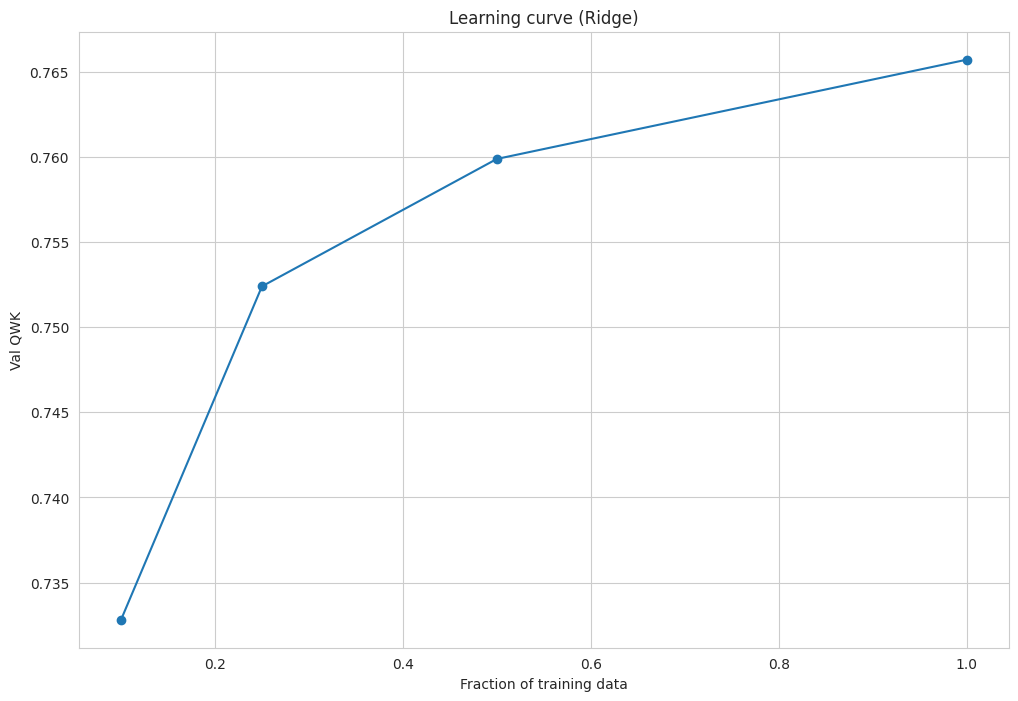

In [85]:
# Ablation 2: Learning curves
fracs = [0.1, 0.25, 0.5, 1.0]
curve_qwk = []
n_train = len(y_train)
for f in fracs:
    n = max(1, int(n_train * f))
    idx = np.random.RandomState(RANDOM_STATE).permutation(n_train)[:n]
    Xt, yt = X_train_feat[idx], y_train.iloc[idx]
    m = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(Xt, yt)
    curve_qwk.append(qwk(y_val, m.predict(X_val_feat)))
plt.plot(fracs, curve_qwk, "o-")
plt.xlabel("Fraction of training data")
plt.ylabel("Val QWK")
plt.title("Learning curve (Ridge)")
plt.show()

# **Interpretability**

In [86]:

n_word_feat = tfidf_word.get_feature_names_out().shape[0]
coef = ridge_final.coef_[:n_word_feat]
names = tfidf_word.get_feature_names_out()
order = np.argsort(coef)
print("Top 10 negative (lower score):", list(zip(names[order[:10]], coef[order[:10]].round(4))))
print("Top 10 positive (higher score):", list(zip(names[order[-10:]][::-1], coef[order[-10:]][::-1].round(4))))

Top 10 negative (lower score): [('suburbs', np.float64(-1.1955)), ('but some', np.float64(-1.0651)), ('31', np.float64(-1.0594)), ('district', np.float64(-0.9966)), ('year', np.float64(-0.9442)), ('your state', np.float64(-0.9261)), ('stuff', np.float64(-0.898)), ('selecting', np.float64(-0.8621)), ('five reasons', np.float64(-0.8377)), ('the', np.float64(-0.8332))]
Top 10 positive (higher score): [('plumer', np.float64(1.1775)), ('how venus', np.float64(0.9917)), ('larger', np.float64(0.9765)), ('exploration', np.float64(0.9753)), ('quality', np.float64(0.9446)), ('size', np.float64(0.9201)), ('enviroment', np.float64(0.9)), ('does not', np.float64(0.8625)), ('far', np.float64(0.8575)), ('money', np.float64(0.8539))]


In [90]:

inv_vocab = {v: k for k, v in vocab.items()}
bilstm_model = model
def get_attention_weights(model, sent_ids):
    model.eval()
    x = torch.LongTensor(sent_ids).unsqueeze(0).to(device)
    mask = (x != 0).float()
    e = model.embed(x)
    out, _ = model.lstm(e)
    scores = model.attn(out).squeeze(-1)
    scores = scores.masked_fill(mask == 0, -1e9)
    a = torch.softmax(scores, dim=1)
    return a.squeeze(0).cpu().detach().numpy(), out.squeeze(0).cpu().detach().numpy()

sample_idx = 0
sample_tokens = X_train_ids[sample_idx]
weights, _ = get_attention_weights(bilstm_model, sample_tokens)
words = [inv_vocab.get(i, "?") for i in sample_tokens if i != 0]
w = weights[:len(words)]
top5 = np.argsort(w)[-5:][::-1]
print("Sample essay (first 50 words):", " ".join(words[:50]))
print("Top 5 attended words:", [(words[i], w[i].round(4)) for i in top5])

Sample essay (first 50 words): the electorial college is not what the people want. isn't this the peoples country, <UNK> by the people for the people. the <UNK> college is good it has our vote in it too but the other half is guys who have great degrees and are all smart wearing suites and
Top 5 attended words: [('i', np.float32(0.0184)), ('need.', np.float32(0.0141)), ('we', np.float32(0.0131)), ('you', np.float32(0.0128)), ('say', np.float32(0.0127))]
